# **Desafio Estatística com Python**
# Frequência e Medidas

### Squad Nina da Hora | Bootcamp Data Analytics 2026.1

## **Configurações Iniciais**

Fonte dos dados: [Kaggle - Netflix Shows and Movies - Exploratory Analysis](https://www.kaggle.com/code/shivamb/netflix-shows-and-movies-exploratory-analysis)

In [5]:
# Importa as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregamento da base de dados sobre catalogo da Netflix via Google Drive
# Armazena o id do arquivo csv e o insere na variavel da url
sheet_id = '1OJk-yF4ZgqyKP9Q6qgfWziiOQEOCV7mML0p0_AjdWGI'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv'

# Le o csv e armazena os dados em um data frame
df = pd.read_csv(url)
df.head(0)

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type


*Variáveis:*
* `show_id` - id único do filme/série.
* `title` - título do filme ou série
* `director` - diretor do filme ou série
* `cast` - elenco do filme ou série
* `country` - país do filme ou série
* `date_added` - data que foi adicionado no Netflix
* `release_year` - ano de lançamento original do filme
* `rating` - classificação da televisão
* `duration` - duração total do filme ou série.
* `listed_in` - categoria ou gênero do filme ou série.
* `description` - descrição do filme ou série.
* `type` - tipo de filme ou série

## **Exploração Inicial**

*   Quantas linhas e colunas tem o dataset?
*   Quais são os tipos das variáveis e se há valores ausentes?

## **Análises de Frequência**

* Qual a proporção de filmes vs. séries no catálogo?
* Qual o gênero mais frequente?

## **Análises Estatísticas**

* Qual a média, mediana e moda do tempo de duração dos
filmes?
* Qual o filme mais curto e mais longo?

## **Visualização de Dados**

* Criar um gráfico de barras para mostrar a quantidade de títulos por gênero.
* Criar um histograma para analisar a distribuição da duração dos
filmes.

## **Atividade Extra**

* Quais são os 5 países que possuem mais produções no catálogo?




In [6]:
# Identificando os 5 países com maior número de produções no catálogo
# Alguns títulos possuem mais de um país associado, por isso os países
# são separados e analisados individualmente

paises = df['country'].dropna().str.split(', ')
paises_explodidos = paises.explode()

top5_paises = (
    paises_explodidos
    .value_counts()
    .head(5)
    .reset_index()
)

top5_paises.columns = ['País', 'Quantidade']

top5_paises.insert(
    0,
    'Ranking',
    range(1, len(top5_paises) + 1)
)

top5_paises

,Ranking,País,Quantidade
0,1,United States,2420
1,2,India,753
2,3,United Kingdom,558
3,4,Canada,300
4,5,France,255


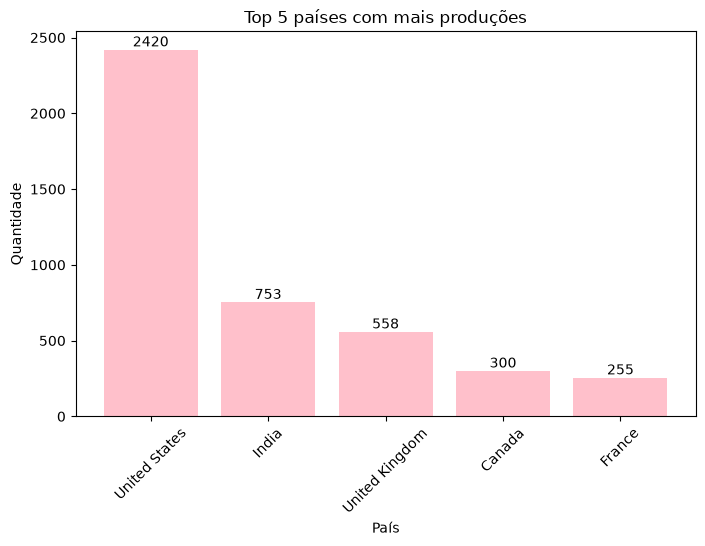

In [7]:
# Visualizando os 5 países com mais produções no catálogo

plt.figure(figsize=(8,5))

ax = plt.bar(
    top5_paises['País'],
    top5_paises['Quantidade'],
    color='pink'
)

plt.title('Top 5 países com mais produções')
plt.xlabel('País')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)

# Exibindo os valores sobre as barras
for bar in ax:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        int(y),
        ha='center',
        va='bottom'
    )

plt.show()